# HW02

## 2.1 


### 2.1.1

隐藏层：

$$
h = W_1 x + b_1
$$

输出层：

$$
o = W_2 h + b_2
$$

代入得到：

$$
o = W_2 (W_1 x + b_1) + b_2
$$

展开：

$$
o = (W_2 W_1)x + (W_2 b_1 + b_2)
$$

因此该网络等价于单层神经网络：

$$
o = W'x + b'
$$

其中：

$$
W' = W_2W_1
$$

$$
b' = W_2b_1+b_2
$$



### 2.1.2

Sigmoid：

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

导数：

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

tanh：

$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

导数：

$$
\tanh'(x)=1-\tanh^2(x)
$$


## 2.2 编程题

In [1]:

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

batch_size = 256

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


100.0%
100.0%
100.0%
100.0%


In [5]:

num_inputs = 784
num_hiddens = 256
num_outputs = 10

W1 = (torch.randn(num_inputs, num_hiddens) * 0.01).requires_grad_()
b1 = torch.zeros(num_hiddens).requires_grad_()

W2 = (torch.randn(num_hiddens, num_outputs) * 0.01).requires_grad_()
b2 = torch.zeros(num_outputs).requires_grad_()

params = [W1, b1, W2, b2]


In [6]:

def relu(X):
    return torch.max(X, torch.zeros_like(X))

def net(X):
    X = X.reshape((-1, 784))
    H = relu(torch.matmul(X, W1) + b1)
    return torch.matmul(H, W2) + b2

def cross_entropy(y_hat, y):
    return -torch.log(torch.softmax(y_hat, dim=1)[range(len(y)), y]).mean()

def accuracy(y_hat, y):
    pred = y_hat.argmax(dim=1)
    return (pred == y).float().mean().item()

def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()


In [7]:

lr = 0.1
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = 0
    train_acc = 0

    for X, y in train_loader:

        y_hat = net(X)
        loss = cross_entropy(y_hat, y)

        loss.backward()

        sgd(params, lr, batch_size)

        train_loss += loss.item()
        train_acc += accuracy(y_hat, y)

    print(f'epoch {epoch+1}, loss {train_loss/len(train_loader):.4f}, acc {train_acc/len(train_loader):.4f}')


epoch 1, loss 2.3006, acc 0.1814
epoch 2, loss 2.2944, acc 0.2068
epoch 3, loss 2.2882, acc 0.2188
epoch 4, loss 2.2818, acc 0.2264
epoch 5, loss 2.2749, acc 0.2339


## 3.1 


### 3.1.1

训练误差是模型在训练集上的误差。

泛化误差是模型在测试集或未知数据上的误差。

训练误差很低但泛化误差很高时，模型发生过拟合。

可以通过减小模型复杂度、加入正则化、Dropout、增加数据量等方法缓解。



### 3.1.2

1. 将数据划分为 K 份。
2. 每次选其中 1 份作为验证集，其余 K-1 份作为训练集。
3. 训练 K 次模型。
4. 记录每次验证误差。
5. 对 K 次结果求平均作为最终评估结果。


## 3.2 编程题

In [8]:

def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1

    if dropout == 1:
        return torch.zeros_like(X)

    if dropout == 0:
        return X

    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)


In [9]:

def net_dropout(X, is_training=True):
    X = X.reshape((-1, 784))

    H1 = relu(torch.matmul(X, W1) + b1)

    if is_training:
        H1 = dropout_layer(H1, 0.5)

    return torch.matmul(H1, W2) + b2

def sgd_weight_decay(params, lr, batch_size, wd):
    with torch.no_grad():
        for param in params:
            param *= (1 - lr * wd)
            param -= lr * param.grad / batch_size
            param.grad.zero_()


In [10]:

train_losses = []
test_losses = []

for epoch in range(5):

    total_loss = 0

    for X, y in train_loader:

        y_hat = net_dropout(X, True)
        loss = cross_entropy(y_hat, y)

        loss.backward()

        sgd_weight_decay(params, 0.1, batch_size, 1e-4)

        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))

    with torch.no_grad():
        test_loss = 0

        for X, y in test_loader:
            y_hat = net_dropout(X, False)
            loss = cross_entropy(y_hat, y)
            test_loss += loss.item()

        test_losses.append(test_loss / len(test_loader))

    print(epoch+1, train_losses[-1], test_losses[-1])


1 2.2677718466900765 2.2643006920814512
2 2.259835419756301 2.256095552444458
3 2.251270850161289 2.2470382273197176
4 2.241570375320759 2.236974984407425
5 2.2308470391212625 2.22579340338707


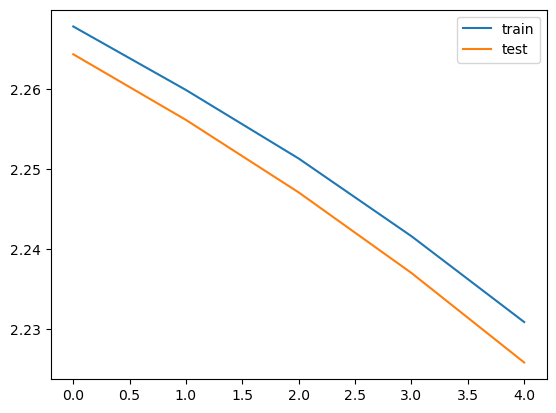

In [11]:

plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.legend()
plt.show()


## 4.1 


### 4.1.1

如果多层矩阵连乘中的特征值大于 1，则梯度会不断放大，出现梯度爆炸。

如果特征值小于 1，则梯度会不断缩小，出现梯度消失。

Sigmoid 和 tanh 导数最大值较小，因此深层网络中容易出现梯度消失。



### 4.1.2

ReLU 在 x>0 时导数恒为 1。

因此梯度能够更稳定地传播，不容易像 Sigmoid 一样连续缩小。


## 4.2 编程题

In [12]:

import torch.nn as nn

model = nn.Sequential()

for i in range(20):
    model.add_module(f'linear{i}', nn.Linear(256, 256))
    model.add_module(f'sigmoid{i}', nn.Sigmoid())

for m in model:
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1)

X = torch.randn(64, 256)
y = model(X).sum()

y.backward()

for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm().item())


linear0.weight 6749.2880859375
linear0.bias 430.5389099121094
linear1.weight 4603.71337890625
linear1.bias 416.8343505859375
linear2.weight 3211.51513671875
linear2.bias 281.4758605957031
linear3.weight 2665.737060546875
linear3.bias 234.03030395507812
linear4.weight 2230.344482421875
linear4.bias 212.33729553222656
linear5.weight 2053.976318359375
linear5.bias 187.33609008789062
linear6.weight 1682.9251708984375
linear6.bias 153.37155151367188
linear7.weight 1136.481201171875
linear7.bias 106.20053100585938
linear8.weight 836.470703125
linear8.bias 78.18293762207031
linear9.weight 762.6998901367188
linear9.bias 69.29576873779297
linear10.weight 730.8868408203125
linear10.bias 66.64234924316406
linear11.weight 616.3884887695312
linear11.bias 54.560813903808594
linear12.weight 474.9490661621094
linear12.bias 45.70604705810547
linear13.weight 441.65179443359375
linear13.bias 40.72539138793945
linear14.weight 381.6023254394531
linear14.bias 36.08272171020508
linear15.weight 341.3302917480

In [13]:

model_relu = nn.Sequential()

for i in range(20):
    model_relu.add_module(f'linear{i}', nn.Linear(256, 256))
    model_relu.add_module(f'relu{i}', nn.ReLU())

for m in model_relu:
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)

X = torch.randn(64, 256)

y = model_relu(X).sum()

y.backward()

for name, param in model_relu.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm().item())


linear0.weight nan
linear0.bias nan
linear1.weight inf
linear1.bias inf
linear2.weight inf
linear2.bias inf
linear3.weight inf
linear3.bias inf
linear4.weight inf
linear4.bias inf
linear5.weight inf
linear5.bias inf
linear6.weight inf
linear6.bias inf
linear7.weight inf
linear7.bias inf
linear8.weight inf
linear8.bias inf
linear9.weight inf
linear9.bias inf
linear10.weight inf
linear10.bias inf
linear11.weight inf
linear11.bias inf
linear12.weight inf
linear12.bias 1.9746533050155008e+17
linear13.weight inf
linear13.bias 2039158935650304.0
linear14.weight inf
linear14.bias 19649286635520.0
linear15.weight inf
linear15.bias 174054948864.0
linear16.weight inf
linear16.bias 1521020928.0
linear17.weight inf
linear17.bias 13552140.0
linear18.weight inf
linear18.bias 120639.8359375
linear19.weight inf
linear19.bias 1024.0


In [14]:

model_fix = nn.Sequential()

for i in range(20):
    model_fix.add_module(f'linear{i}', nn.Linear(256, 256))
    model_fix.add_module(f'relu{i}', nn.ReLU())

for m in model_fix:
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)

X = torch.randn(64, 256)

y = model_fix(X).sum()

y.backward()

for name, param in model_fix.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm().item())


linear0.weight 2.319047689437866
linear0.bias 0.2733262777328491
linear1.weight 3.6790757179260254
linear1.bias 0.48890024423599243
linear2.weight 4.637590408325195
linear2.bias 0.7742965817451477
linear3.weight 5.754420280456543
linear3.bias 1.3620541095733643
linear4.weight 7.516254901885986
linear4.bias 2.2970993518829346
linear5.weight 8.374825477600098
linear5.bias 3.752335786819458
linear6.weight 9.145139694213867
linear6.bias 5.821212291717529
linear7.weight 11.907145500183105
linear7.bias 9.287620544433594
linear8.weight 15.644662857055664
linear8.bias 15.97046947479248
linear9.weight 18.504348754882812
linear9.bias 22.080965042114258
linear10.weight 23.86882972717285
linear10.bias 31.277935028076172
linear11.weight 30.943998336791992
linear11.bias 44.19850540161133
linear12.weight 40.64519119262695
linear12.bias 65.9073486328125
linear13.weight 69.84783172607422
linear13.bias 103.89606475830078
linear14.weight 100.47521209716797
linear14.bias 154.5401153564453
linear15.weight 

## 5.1 


### 5.1

协变量偏移：输入数据分布发生变化，但标签条件分布不变。

例如训练时使用白天道路图像，测试时使用夜晚道路图像。

标签偏移：标签分布发生变化，但同类别数据特征分布不变。

例如医院中某种疾病突然流行，导致阳性病例比例增加。


## 5.2 编程题

In [15]:

import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

np.random.seed(0)

X_train = np.random.normal(-1, 1, (1000, 1))
y_train = 2 * X_train.squeeze() + np.random.normal(0, 0.1, 1000)

X_test = np.random.normal(2, 1, (500, 1))
y_test = 2 * X_test.squeeze() + np.random.normal(0, 0.1, 500)


In [16]:

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

mse = mean_squared_error(y_test, pred)

print("baseline mse:", mse)


baseline mse: 0.008844659363669682


In [17]:

X_mix = np.vstack([X_train, X_test])

y_domain = np.array([0] * len(X_train) + [1] * len(X_test))

clf = LogisticRegression()

clf.fit(X_mix, y_domain)

p_test = clf.predict_proba(X_train)[:, 1]

weights = p_test / (1 - p_test)


In [18]:

weighted_model = LinearRegression()

weighted_model.fit(X_train, y_train, sample_weight=weights)

pred2 = weighted_model.predict(X_test)

mse2 = mean_squared_error(y_test, pred2)

print("weighted mse:", mse2)


weighted mse: 0.011101274301897817
